In [1]:
import xarray as xr
import sys, os
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
#print(curdir)
sys.path.insert(0, curdir+"/../../../data_processing")
from ceres_ebaf import *

sys.path.insert(0, curdir+"/../../../visualization")
from ceres_ebaf_plotting import *

base_path = AnyPath("/Users/mawa7160/dev/data/CERES/EBAF/")
full_ebaf_filename = "CERES_EBAF-TOA_Ed4.2_Subset_200003-202402.nc"
global_ebaf_filename = "CERES_EBAF-TOA_Ed4.2_Subset_200003-202402_global.nc"

plt.rcParams['figure.figsize'] = [10, 3.5]

In [2]:
# Load the data
full_data_path = base_path / full_ebaf_filename
global_average_data_path = base_path / global_ebaf_filename

ds = xr.open_dataset(full_data_path)
ds_global = xr.open_dataset(global_average_data_path)

# Single Year Example

In [3]:
full_data_2022 = ds["solar_mon"].sel(time=slice("2022-1-15", "2022-12-15"))

global_average = apply_spatial_weights(full_data_2022)
no_weight = apply_time_averaging(global_average, averaging_method=-1).values[0]
days_weight = apply_time_averaging(global_average, averaging_method=0).values[0]
num_leap_year = apply_time_averaging(global_average, averaging_method=1).values[0]
month_14 = apply_time_averaging(global_average, averaging_method=2).values[0]

In [4]:
nh_2022 = apply_spatial_weights(full_data_2022, low_lat=0, high_lat=90)
nh_unweighted = apply_time_averaging(nh_2022, averaging_method=-1).values[0]
sh_2022 = apply_spatial_weights(full_data_2022, low_lat=-90, high_lat=0)
sh_unweighted = apply_time_averaging(sh_2022, averaging_method=-1).values[0]

In [5]:
print(f"Global Yearly Average - No Weighting: {no_weight}")
print(f"Global Yearly Average - Days of Month Weighting: {days_weight}")
print(f"Global Yearly Average - Leap Year Corrected Weighting: {num_leap_year}")
print(f"Global Yearly Average - 14 Month Leap Year Weighting: {month_14}")

print(f"Percent Difference to 14 month Leap Year Average- No Weighting: {100*(no_weight - month_14)/month_14}")
print(f"Percent Difference to 14 month Leap Year Average- Days of Month Weighting: {100*(days_weight - month_14)/month_14}")
print(f"Percent Difference to 14 month Leap Year Average- Leap Year Corrected Weighting: {100*(num_leap_year - month_14)/month_14}")

Global Yearly Average - No Weighting: 340.3618897597141
Global Yearly Average - Days of Month Weighting: 340.31817982450843
Global Yearly Average - Leap Year Corrected Weighting: 340.32861151283873
Global Yearly Average - 14 Month Leap Year Weighting: 340.3255026695556
Percent Difference to 14 month Leap Year Average- No Weighting: 0.010691849383328537
Percent Difference to 14 month Leap Year Average- Days of Month Weighting: -0.0021517179846102545
Percent Difference to 14 month Leap Year Average- Leap Year Corrected Weighting: 0.0009134911309195802


Text(0.5, 1.0, 'Incorrect Temporal Hemispheric Averaging')

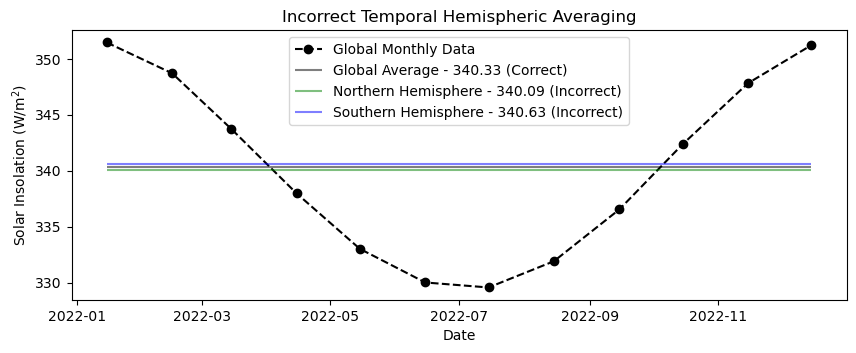

In [6]:
plt.plot(global_average.time, global_average, '--ok', label="Global Monthly Data")
plt.hlines(num_leap_year, global_average.time[0], global_average.time[-1], colors='black', linestyles='solid', label=f"Global Average - {round(month_14,2)} (Correct)", alpha=0.5)
plt.hlines(nh_unweighted, global_average.time[0], global_average.time[-1], colors='green', linestyles='solid', label=f"Northern Hemisphere - {round(nh_unweighted,2)} (Incorrect)", alpha=0.5)
plt.hlines(sh_unweighted, global_average.time[0], global_average.time[-1], colors='blue', linestyles='solid', label=f"Southern Hemisphere - {round(sh_unweighted,2)} (Incorrect)", alpha=0.5)
plt.legend()
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Date")
plt.title("Incorrect Temporal Hemispheric Averaging")

In [7]:
print(f"NH Yearly Average - No Weighting: {nh_unweighted}")
print(f"SH Yearly Average - No Weighting: {sh_unweighted}")

NH Yearly Average - No Weighting: 340.0929826165674
SH Yearly Average - No Weighting: 340.6307974406564


# Four Year Example

In [8]:
four_year_data = ds["solar_mon"].sel(time=slice("2018-1-15", "2022-12-15"))

global_average = apply_spatial_weights(four_year_data)
no_weight = apply_time_averaging(global_average, averaging_method=-1).values[0]
days_weight = apply_time_averaging(global_average, averaging_method=0).values[0]
num_leap_year = apply_time_averaging(global_average, averaging_method=1).values[0]
month_14 = apply_time_averaging(global_average, averaging_method=2).values[0]

In [9]:
print(f"Global 4-Year Average - No Weighting: {no_weight}")
print(f"Global 4-Year Average - Days of Month Weighting: {days_weight}")
print(f"Global 4-Year Average - Leap Year Corrected Weighting: {num_leap_year}")
print(f"Global 4-Year Average - 14 Month Leap Year Weighting: {month_14}")

Global 4-Year Average - No Weighting: 340.11612158334987
Global 4-Year Average - Days of Month Weighting: 340.07287298178136
Global 4-Year Average - Leap Year Corrected Weighting: 340.08326395128825
Global 4-Year Average - 14 Month Leap Year Weighting: 340.0802338432033


In [10]:
print(f"Percent Difference to 14 month Leap Year Average- No Weighting: {100*(no_weight - month_14)/month_14}")
print(f"Percent Difference to 14 month Leap Year Average- Days of Month Weighting: {100*(days_weight - month_14)/month_14}")
print(f"Percent Difference to 14 month Leap Year Average- Leap Year Corrected Weighting: {100*(num_leap_year - month_14)/month_14}")

Percent Difference to 14 month Leap Year Average- No Weighting: 0.010552727437581597
Percent Difference to 14 month Leap Year Average- Days of Month Weighting: -0.0021644484711033202
Percent Difference to 14 month Leap Year Average- Leap Year Corrected Weighting: 0.0008909980008834313


# Incorrect Hemispheric Averaging

<xarray.DataArray 'global' ()>
array(340.14267661)
<xarray.DataArray 'nh' ()>
array(340.13731027)
<xarray.DataArray 'sh' ()>
array(340.14804296)


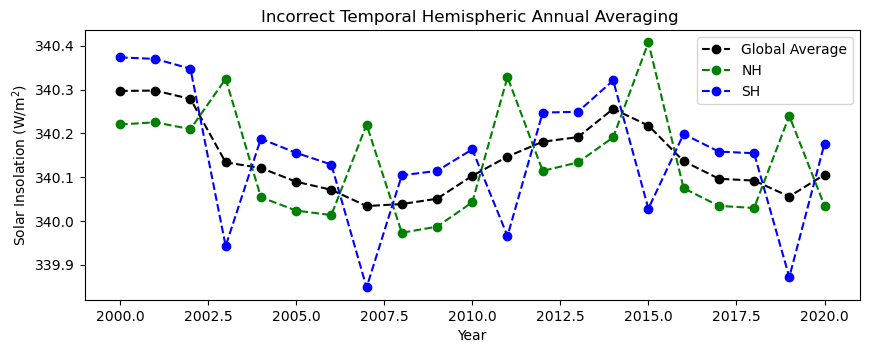

In [11]:
four_year_avgs = create_hemisphere_data(ds["solar_mon"], time_weighting=1, start_yr="2000", end_yr="2022")
# Plot the averages across the four years for global, NH, and SH
plt.plot(four_year_avgs.year, four_year_avgs["global"], '--ok', label="Global Average")
plt.plot(four_year_avgs.year, four_year_avgs["nh"], '--og', label="NH")
plt.plot(four_year_avgs.year, four_year_avgs["sh"], '--ob', label="SH")
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Year")
plt.title("Incorrect Temporal Hemispheric Annual Averaging ")
plt.legend()
print(four_year_avgs["global"].mean())
print(four_year_avgs["nh"].mean())
print(four_year_avgs["sh"].mean())

# Correct Hemispheric Averaging

<xarray.DataArray 'global' ()>
array(340.10114014)
<xarray.DataArray 'nh' ()>
array(340.09648693)
<xarray.DataArray 'sh' ()>
array(340.10579336)


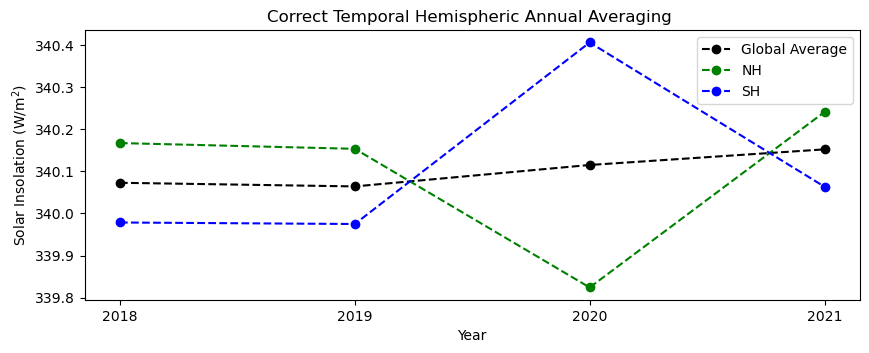

In [12]:
four_year_avgs = create_hemisphere_data(ds["solar_mon"], time_weighting=0, start_yr="2018", end_yr="2022")
# Plot the averages across the four years for global, NH, and SH
plt.plot(four_year_avgs.year, four_year_avgs["global"], '--ok', label="Global Average")
plt.plot(four_year_avgs.year, four_year_avgs["nh"], '--og', label="NH")
plt.plot(four_year_avgs.year, four_year_avgs["sh"], '--ob', label="SH")
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Year")
plt.title("Correct Temporal Hemispheric Annual Averaging ")
plt.xticks([2018, 2019, 2020, 2021])
plt.legend()
print(four_year_avgs["global"].mean())
print(four_year_avgs["nh"].mean())
print(four_year_avgs["sh"].mean())

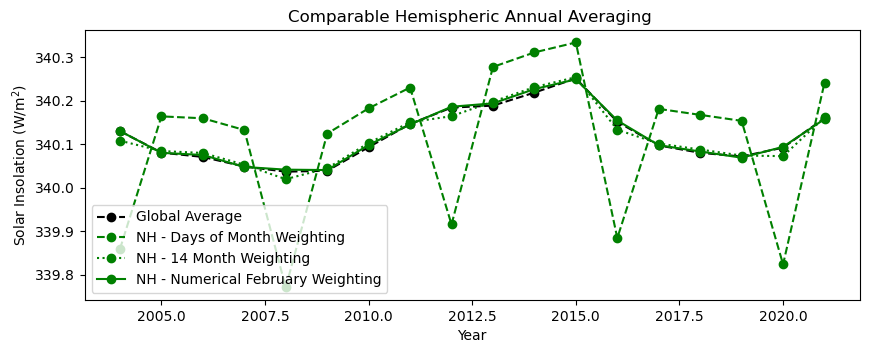

In [28]:
four_year_avgs_ok = create_hemisphere_data(ds["solar_mon"], time_weighting=0, start_yr="2004", end_yr="2022")
four_year_avgs_good = create_hemisphere_data(ds["solar_mon"], time_weighting=2, start_yr="2004", end_yr="2022")
four_year_avgs_best = create_hemisphere_data(ds["solar_mon"], time_weighting=1, start_yr="2004", end_yr="2022", ly_feb=27.55, nly_feb=28.45)
# Plot the averages across the four years for global, NH, and SH
plt.plot(four_year_avgs_ok.year, four_year_avgs_good["global"], '--ok', label="Global Average")
plt.plot(four_year_avgs_ok.year, four_year_avgs_ok["nh"], '--og', label="NH - Days of Month Weighting")
plt.plot(four_year_avgs_ok.year, four_year_avgs_good["nh"], 'g', label="NH - 14 Month Weighting", linestyle='dotted', marker='o')
plt.plot(four_year_avgs_ok.year, four_year_avgs_best["nh"], '-og', label="NH - Numerical February Weighting")
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Year")
plt.title("Comparable Hemispheric Annual Averaging ")
#plt.xticks([2018, 2019, 2020, 2021])
plt.legend();

# CERES Record and Errors

In [14]:
twenty_two_ok = create_hemisphere_data(ds["solar_mon"], time_weighting=0, start_yr="2001", end_yr="2023")
twenty_two_good = create_hemisphere_data(ds["solar_mon"], time_weighting=2, start_yr="2001", end_yr="2023")
twenty_two_best = create_hemisphere_data(ds["solar_mon"], time_weighting=1, start_yr="2001", end_yr="2023", ly_feb=27.55, nly_feb=28.45)

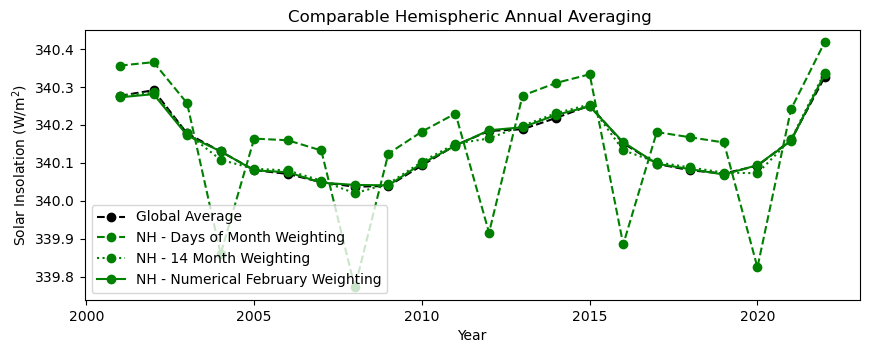

In [15]:
plt.plot(twenty_two_ok.year, twenty_two_good["global"], '--ok', label="Global Average")
plt.plot(twenty_two_ok.year, twenty_two_ok["nh"], '--og', label="NH - Days of Month Weighting")
plt.plot(twenty_two_ok.year, twenty_two_good["nh"], 'g', label="NH - 14 Month Weighting", linestyle='dotted', marker='o')
plt.plot(twenty_two_ok.year, twenty_two_best["nh"], '-og', label="NH - Numerical February Weighting")
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Year")
plt.title("Comparable Hemispheric Annual Averaging ")
plt.legend();

In [16]:
nh_diff_per_year_month = 100*np.abs(twenty_two_ok["nh"] - twenty_two_good["global"])/twenty_two_good["global"]
nh_diff_per_year_num = 100*np.abs(twenty_two_best["nh"] - twenty_two_good["global"])/twenty_two_good["global"]
nh_diff_per_year_14 = 100*np.abs(twenty_two_good["nh"] - twenty_two_good["global"])/twenty_two_good["global"]

print(f"Largest Percent Difference to Global Average- NH Days of Month Weighting: {nh_diff_per_year_month.max().values}%")
print(f"Largest Percent Difference to Global Average- NH Numerical February Weighting: {nh_diff_per_year_num.max().values}%")
print(f"Largest Percent Difference to Global Average- NH 14 Month Weighting: {nh_diff_per_year_14.max().values}%")
print()
print(f"Mean Percent Difference to Global Average- NH Days of Month Weighting: {nh_diff_per_year_month.mean().values}%")
print(f"Mean Percent Difference to Global Average- NH Numerical February Weighting: {nh_diff_per_year_num.mean().values}%")
print(f"Mean Percent Difference to Global Average- NH 14 Month Weighting: {nh_diff_per_year_14.mean().values}%")

Largest Percent Difference to Global Average- NH Days of Month Weighting: 0.07952763278979239%
Largest Percent Difference to Global Average- NH Numerical February Weighting: 0.0030183481956963213%
Largest Percent Difference to Global Average- NH 14 Month Weighting: 0.006447143565195877%

Mean Percent Difference to Global Average- NH Days of Month Weighting: 0.03710346021060817%
Mean Percent Difference to Global Average- NH Numerical February Weighting: 0.0010109726986424908%
Mean Percent Difference to Global Average- NH 14 Month Weighting: 0.0025652531996558543%


In [17]:
nh_mean_squared_error_month = mean_squared_error(twenty_two_good["global"], twenty_two_ok["nh"])
nh_mean_squared_error_num = mean_squared_error(twenty_two_good["global"], twenty_two_best["nh"])
nh_mean_squared_error_14 = mean_squared_error(twenty_two_good["global"], twenty_two_good["nh"])

print(f"Mean Squared Error to Global Average- NH Days of Month Weighting: {nh_mean_squared_error_month}")
print(f"Mean Squared Error to Global Average- NH Numerical February Weighting: {nh_mean_squared_error_num}")
print(f"Mean Squared Error to Global Average- NH 14 Month Weighting: {nh_mean_squared_error_14}")

Mean Squared Error to Global Average- NH Days of Month Weighting: 0.02184991656509698
Mean Squared Error to Global Average- NH Numerical February Weighting: 1.863028969394211e-05
Mean Squared Error to Global Average- NH 14 Month Weighting: 0.00012104128327707124


# Hemispheric Example

In [18]:
full_data_2020 = ds["solar_mon"].sel(time=slice("2023-1-15", "2023-12-15"))
global_2020 = apply_spatial_weights(full_data_2020)
nh_2020 = apply_spatial_weights(full_data_2020, low_lat=0, high_lat=90)
sh_2020 = apply_spatial_weights(full_data_2020, low_lat=-90, high_lat=0)
full_data = ds["solar_mon"]

no_weight_hemi = create_hemisphere_data(full_data, time_weighting=-1, start_yr="2020", end_yr="2021")
days_weight_hemi = create_hemisphere_data(full_data, time_weighting=0, start_yr="2020", end_yr="2021")
num_leap_year_hemi = create_hemisphere_data(full_data, time_weighting=1, start_yr="2020", end_yr="2021")
month_14_hemi = create_hemisphere_data(full_data, time_weighting=2, start_yr="2020", end_yr="2021")

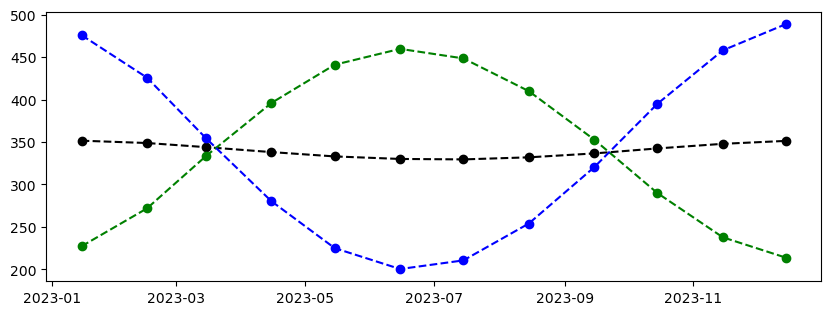

In [19]:
plt.plot(global_2020.time, global_2020, '--ok', label="Global Average")
plt.plot(nh_2020.time, nh_2020, '--og', label="Northern Hemisphere")
plt.plot(sh_2020.time, sh_2020, '--ob', label="Southern Hemisphere")


In [20]:
print(f"NH Yearly Average - No Weighting: {no_weight_hemi['nh'].values[0]}")
print(f"NH Yearly Average - Days of Month Weighting: {days_weight_hemi['nh'].values[0]}")
print(f"NH Yearly Average - Leap Year Corrected Weighting: {num_leap_year_hemi['nh'].values[0]}")
print(f"NH Yearly Average - 14 Month Leap Year Weighting: {month_14_hemi['nh'].values[0]}")

NH Yearly Average - No Weighting: 339.68682073990374
NH Yearly Average - Days of Month Weighting: 339.82412830410834
NH Yearly Average - Leap Year Corrected Weighting: 340.07517511302547
NH Yearly Average - 14 Month Leap Year Weighting: 340.07254349864974


In [21]:
print(f"SH Yearly Average - No Weighting: {no_weight_hemi['sh'].values[0]}")
print(f"SH Yearly Average - Days of Month Weighting: {days_weight_hemi['sh'].values[0]}")
print(f"SH Yearly Average - Leap Year Corrected Weighting: {num_leap_year_hemi['sh'].values[0]}")
print(f"SH Yearly Average - 14 Month Leap Year Weighting: {month_14_hemi['sh'].values[0]}")

SH Yearly Average - No Weighting: 340.584309936951
SH Yearly Average - Days of Month Weighting: 340.4062413238069
SH Yearly Average - Leap Year Corrected Weighting: 340.09325592516234
SH Yearly Average - 14 Month Leap Year Weighting: 340.1116755606607


In [22]:
print(f"Percent Difference to Global Average- NH No Weighting: {100*(no_weight_hemi['nh'].values[0] - month_14_hemi['global'].values[0])/month_14_hemi['global'].values[0]}")
print(f"Percent Difference to Global Average- NH Days of Month Weighting: {100*(days_weight_hemi['nh'].values[0] - month_14_hemi['global'].values[0])/month_14_hemi['global'].values[0]}")
print(f"Percent Difference to Global Average- NH Leap Year Corrected Weighting: {100*(num_leap_year_hemi['nh'].values[0] - month_14_hemi['global'].values[0])/month_14_hemi['global'].values[0]}")
print(f"Percent Difference to Global Average- NH 14 Month Leap Year Weighting: {100*(month_14_hemi['nh'].values[0] - month_14_hemi['global'].values[0])/month_14_hemi['global'].values[0]}")

Percent Difference to Global Average- NH No Weighting: -0.11917029500492289
Percent Difference to Global Average- NH Days of Month Weighting: -0.07879665493359134
Percent Difference to Global Average- NH Leap Year Corrected Weighting: -0.0049793560616009265
Percent Difference to Global Average- NH 14 Month Leap Year Weighting: -0.005753150660811343
